#
## t = 0 → 완전 원본 MNIST 이미지
## t = 1 → 아주 약간 흐릿
## t = 5 → 노이즈가 조금 섞임
## t = 20→ 거의 점점점처럼 보임
## t = 200 →디테일이 거의 없음, 숫자 그림 거의 사라짐
## t = 500→ 랜덤 점 흩뿌려진 형태
## t = 999→ 완전 Gaussian Noise (파지 않으면 원본 x₀ 정보 0)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.82MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 161kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.87MB/s]


loss: 0.033653777092695236


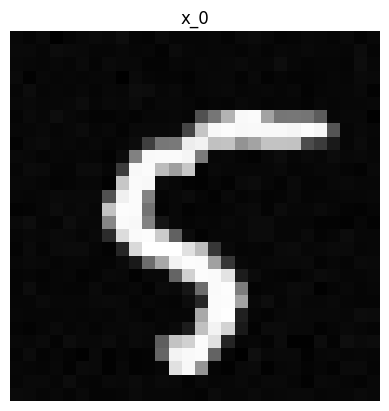

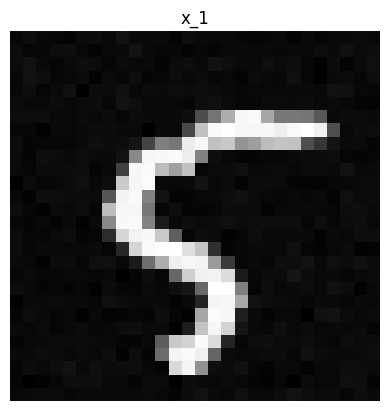

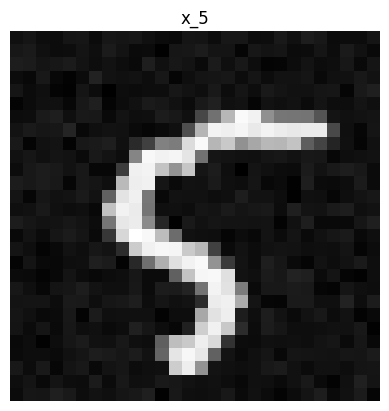

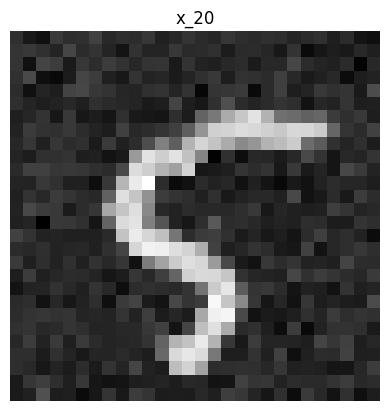

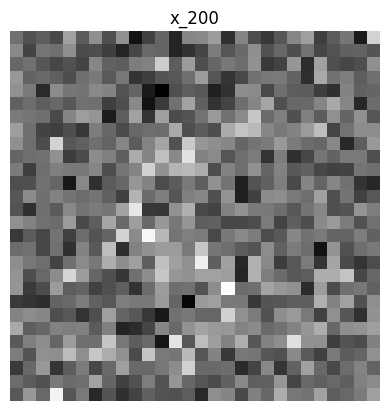

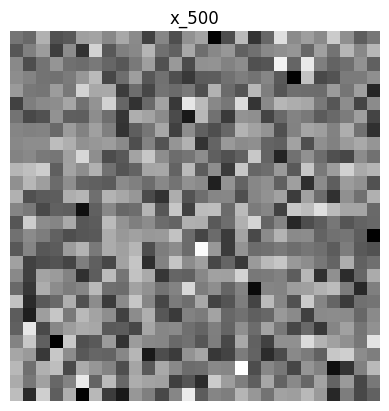

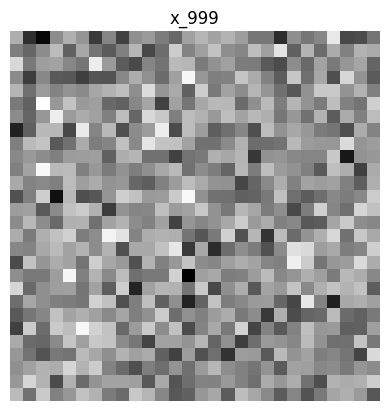

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


# =========================================
# 1. MNIST DATASET
# =========================================
transform = transforms.ToTensor()

mnist = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
loader = DataLoader(mnist, batch_size=64, shuffle=True)


# =========================================
# 2. 노이즈 스케줄: β_t, α_t, α_bar_t 만들기
# =========================================
T = 1000  # diffusion steps
beta = torch.linspace(1e-4, 0.02, T)  # linear schedule
alpha = 1 - beta
alpha_bar = torch.cumprod(alpha, dim=0)  # 누적곱


# =========================================
# 3. Forward Noise Function (핵심 수식)
# x_t = sqrt(ā_t)x0 + sqrt(1-ā_t) * noise
# =========================================
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)

    # t: (batch,)
    # alpha_bar[t]: (batch)
    sqrt_ab = torch.sqrt(alpha_bar[t]).view(-1, 1, 1, 1)
    sqrt_1_ab = torch.sqrt(1 - alpha_bar[t]).view(-1, 1, 1, 1)

    return sqrt_ab * x0 + sqrt_1_ab * noise


# =========================================
# 4. 매우 간단한 "Noise Predictor" 신경망 (UNet 대체)
# 입력: x_t (노이즈 섞인 이미지)
# 출력: ε_t (원래 노이즈)
# =========================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 1, 3, padding=1)
        )

    def forward(self, x):
        return self.net(x)


model = SimpleCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()


# =========================================
# 5. 1 에폭만 예시 학습 (핵심: ε 예측)
# =========================================
for epoch in range(1):

    for x0, _ in loader:
        batch = x0.size(0)

        # 0~T 사이의 랜덤 timestep 선택
        t = torch.randint(0, T, (batch,))

        # 노이즈 생성
        noise = torch.randn_like(x0)

        # Forward: x_t 만들기
        x_t = q_sample(x0, t, noise)

        # 모델이 예측해야 하는 정답은 noise
        pred_noise = model(x_t)

        loss = criterion(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("loss:", loss.item())


# =========================================
# 6. 노이즈 단계별 시각화 (MNIST 한 장)
# =========================================
def show(img, title="image"):
    plt.imshow(img.squeeze().detach().cpu(), cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

# MNIST 한 장 가져오기
x0, _ = next(iter(loader))
x0 = x0[:1]  # 1장만

# t 값 몇 개 선택
steps = [0, 1, 5, 20, 200, 500, 999]

for s in steps:
    t = torch.tensor([s])
    xt = q_sample(x0, t)
    show(xt, title=f"x_{s}")
